# Compare SPARCS Models

This notebook compares the XGBoost, LightGBM, and CatBoost models trained on the SPARCS 2024 dataset.

All models were trained using the same processed dataset, selected feature schema, and train/validation/test split to ensure a fair comparison.

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
BASE_DIR = "/content/drive/MyDrive/FYP/SPARCS"

RESULT_DIR = f"{BASE_DIR}/results"
MODEL_DIR = f"{BASE_DIR}/models"

In [21]:
# Load Model Metrics
# Here combine the three model validation/test metrics and convert into one table

xgb_metrics = pd.read_csv(f"{RESULT_DIR}/xgboost_sparcs_metrics.csv")
lgbm_metrics = pd.read_csv(f"{RESULT_DIR}/lightgbm_sparcs_metrics.csv")
cat_metrics = pd.read_csv(f"{RESULT_DIR}/catboost_sparcs_metrics.csv")

all_metrics = pd.concat(
    [xgb_metrics, lgbm_metrics, cat_metrics],
    ignore_index=True
)

all_metrics

,model,dataset,split,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1
0,XGBoost,SPARCS 2024,validation,0.55,0.866515,0.680567,0.799088,0.564512,0.729842,0.636618
1,XGBoost,SPARCS 2024,test,0.55,0.865857,0.679612,0.798358,0.563394,0.727797,0.635129
2,LightGBM,SPARCS 2024,validation,0.60,0.879007,0.712681,0.817730,0.601581,0.722857,0.656666
3,LightGBM,SPARCS 2024,test,0.60,0.878120,0.711166,0.817480,0.601391,0.720916,0.655751
4,CatBoost,SPARCS 2024,validation,0.60,0.869825,0.687936,0.813203,0.595169,0.704639,0.645294
5,CatBoost,SPARCS 2024,test,0.60,0.869195,0.686553,0.813027,0.595167,0.702378,0.644343


In [22]:
# Separate Validation and Test Result
# Validation metrics are the results used in the threshold selection and model tuning processes.
# Test metrics are the primary basis for the final comparison

validation_metrics = all_metrics[all_metrics["split"] == "validation"].copy()
test_metrics = all_metrics[all_metrics["split"] == "test"].copy()

validation_metrics

,model,dataset,split,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1
0,XGBoost,SPARCS 2024,validation,0.55,0.866515,0.680567,0.799088,0.564512,0.729842,0.636618
2,LightGBM,SPARCS 2024,validation,0.60,0.879007,0.712681,0.817730,0.601581,0.722857,0.656666
4,CatBoost,SPARCS 2024,validation,0.60,0.869825,0.687936,0.813203,0.595169,0.704639,0.645294


In [23]:
test_metrics

,model,dataset,split,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1
1,XGBoost,SPARCS 2024,test,0.55,0.865857,0.679612,0.798358,0.563394,0.727797,0.635129
3,LightGBM,SPARCS 2024,test,0.60,0.878120,0.711166,0.817480,0.601391,0.720916,0.655751
5,CatBoost,SPARCS 2024,test,0.60,0.869195,0.686553,0.813027,0.595167,0.702378,0.644343


In [24]:
# Test Performance Comparison
# For compare which model has the best performance

comparison_cols = [
    "model",
    "threshold",
    "roc_auc",
    "pr_auc",
    "accuracy",
    "precision",
    "recall",
    "f1"
]

test_comparison = test_metrics[comparison_cols].sort_values(
    by=["roc_auc", "pr_auc", "f1"],
    ascending=False
)

test_comparison

,model,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1
3,LightGBM,0.60,0.878120,0.711166,0.817480,0.601391,0.720916,0.655751
5,CatBoost,0.60,0.869195,0.686553,0.813027,0.595167,0.702378,0.644343
1,XGBoost,0.55,0.865857,0.679612,0.798358,0.563394,0.727797,0.635129


In [25]:
# Validation Performance Comparison
# Validation comparison can help confirm whether the model performs consistently in validation and testing
# If a model performs well in validation but poorly in testing, there may be overfitting concerns.

validation_comparison = validation_metrics[comparison_cols].sort_values(
    by=["roc_auc", "pr_auc", "f1"],
    ascending=False
)

validation_comparison

,model,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1
2,LightGBM,0.60,0.879007,0.712681,0.817730,0.601581,0.722857,0.656666
4,CatBoost,0.60,0.869825,0.687936,0.813203,0.595169,0.704639,0.645294
0,XGBoost,0.55,0.866515,0.680567,0.799088,0.564512,0.729842,0.636618


In [26]:
# Ranking Table
# This table combines multiple metrics for a single view

ranking_df = test_metrics.copy()

ranking_df["roc_auc_rank"] = ranking_df["roc_auc"].rank(ascending=False)
ranking_df["pr_auc_rank"] = ranking_df["pr_auc"].rank(ascending=False)
ranking_df["recall_rank"] = ranking_df["recall"].rank(ascending=False)
ranking_df["f1_rank"] = ranking_df["f1"].rank(ascending=False)

ranking_df["average_rank"] = ranking_df[
    ["roc_auc_rank", "pr_auc_rank", "recall_rank", "f1_rank"]
].mean(axis=1)

ranking_df = ranking_df.sort_values("average_rank")

ranking_df[[
    "model",
    "threshold",
    "roc_auc",
    "pr_auc",
    "precision",
    "recall",
    "f1",
    "roc_auc_rank",
    "pr_auc_rank",
    "recall_rank",
    "f1_rank",
    "average_rank"
]]

,model,threshold,roc_auc,pr_auc,precision,recall,f1,roc_auc_rank,pr_auc_rank,recall_rank,f1_rank,average_rank
3,LightGBM,0.60,0.878120,0.711166,0.601391,0.720916,0.655751,1.0,1.0,2.0,1.0,1.25
5,CatBoost,0.60,0.869195,0.686553,0.595167,0.702378,0.644343,2.0,2.0,3.0,2.0,2.25
1,XGBoost,0.55,0.865857,0.679612,0.563394,0.727797,0.635129,3.0,3.0,1.0,3.0,2.50


# Select Best Model

The best model is selected using the following criteria:

1. Recall must remain above 0.70 where possible, because missing prolonged LOS cases is clinically undesirable.
2. Among eligible models, ROC-AUC and PR-AUC are prioritized because they evaluate ranking quality and positive-class performance.
3. F1-score is used as an additional balance metric.

In [27]:
eligible_models = test_metrics[test_metrics["recall"] >= 0.70].copy()

if len(eligible_models) == 0:
    eligible_models = test_metrics.copy()

best_model_row = eligible_models.sort_values(
    by=["roc_auc", "pr_auc", "f1"],
    ascending=False
).iloc[0]

best_model_row

,3
model,LightGBM
dataset,SPARCS 2024
split,test
threshold,0.6
roc_auc,0.87812
pr_auc,0.711166
accuracy,0.81748
precision,0.601391
recall,0.720916
f1,0.655751


In [28]:
# Save Best Model Selection

best_model_name = best_model_row["model"]

model_file_map = {
    "XGBoost": "xgboost_sparcs_los_pipeline.joblib",
    "LightGBM": "lightgbm_sparcs_los_pipeline.joblib",
    "CatBoost": "catboost_sparcs_los_pipeline.joblib"
}

metadata_file_map = {
    "XGBoost": "xgboost_sparcs_metadata.joblib",
    "LightGBM": "lightgbm_sparcs_metadata.joblib",
    "CatBoost": "catboost_sparcs_metadata.joblib"
}

best_model_info = {
    "best_model": best_model_name,
    "best_model_file": model_file_map[best_model_name],
    "best_metadata_file": metadata_file_map[best_model_name],
    "selection_reason": (
        "Selected based on highest test ROC-AUC and PR-AUC among models "
        "with recall above 0.70."
    ),
    "test_metrics": best_model_row.to_dict()
}

joblib.dump(best_model_info, f"{MODEL_DIR}/best_model_selection.joblib")

best_model_info

{'best_model': 'LightGBM',
 'best_model_file': 'lightgbm_sparcs_los_pipeline.joblib',
 'best_metadata_file': 'lightgbm_sparcs_metadata.joblib',
 'selection_reason': 'Selected based on highest test ROC-AUC and PR-AUC among models with recall above 0.70.',
 'test_metrics': {'model': 'LightGBM',
  'dataset': 'SPARCS 2024',
  'split': 'test',
  'threshold': 0.5999999999999999,
  'roc_auc': 0.878119525989046,
  'pr_auc': 0.7111659540917288,
  'accuracy': 0.8174795378606481,
  'precision': 0.6013905621304104,
  'recall': 0.7209159642449242,
  'f1': 0.6557512170411519}}

In [29]:
import joblib

lgbm_pipeline = joblib.load(f"{MODEL_DIR}/lightgbm_sparcs_los_pipeline.joblib")
metadata = joblib.load(f"{MODEL_DIR}/lightgbm_sparcs_metadata.joblib")

deployment_threshold = metadata["selected_threshold"]

In [31]:
# Load Test Set for Confusion Matrix

import numpy as np

PROCESSED_PATH = f"{BASE_DIR}/processed/sparcs_2024_processed.csv"
SPLIT_DIR = f"{BASE_DIR}/splits"

df = pd.read_csv(PROCESSED_PATH, low_memory=False)

test_idx = np.load(f"{SPLIT_DIR}/test_idx.npy")
feature_columns = joblib.load(f"{SPLIT_DIR}/feature_columns.joblib")

X = df[feature_columns].copy()
y = df["prolonged_los"].copy()

X_test = X.iloc[test_idx]
y_test = y.iloc[test_idx]

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("Positive class count:", y_test.sum())

X_test: (439348, 13)
y_test: (439348,)
Positive class count: 105943


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


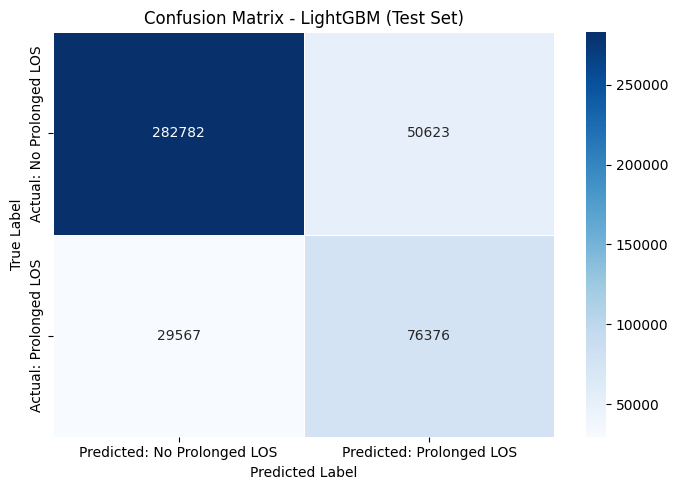

In [32]:
# Confusion Matrix for Selected Model (LightGBM)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

deployment_threshold = metadata["selected_threshold"]

y_prob_test = lgbm_pipeline.predict_proba(X_test)[:, 1]
y_pred_test = (y_prob_test >= deployment_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_test, labels=[0, 1])

cm_df = pd.DataFrame(
    cm,
    index=["Actual: No Prolonged LOS", "Actual: Prolonged LOS"],
    columns=["Predicted: No Prolonged LOS", "Predicted: Prolonged LOS"]
)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    cbar=True
)

plt.title("Confusion Matrix - LightGBM (Test Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

plt.savefig(f"{RESULT_DIR}/lightgbm_confusion_matrix_test.png", dpi=300, bbox_inches="tight")
plt.show()

In [33]:
# Save Comparison Results

test_comparison.to_csv(f"{RESULT_DIR}/model_comparison_test.csv", index=False)
validation_comparison.to_csv(f"{RESULT_DIR}/model_comparison_validation.csv", index=False)
ranking_df.to_csv(f"{RESULT_DIR}/model_comparison_ranking.csv", index=False)

print("Saved model comparison results.")

Saved model comparison results.


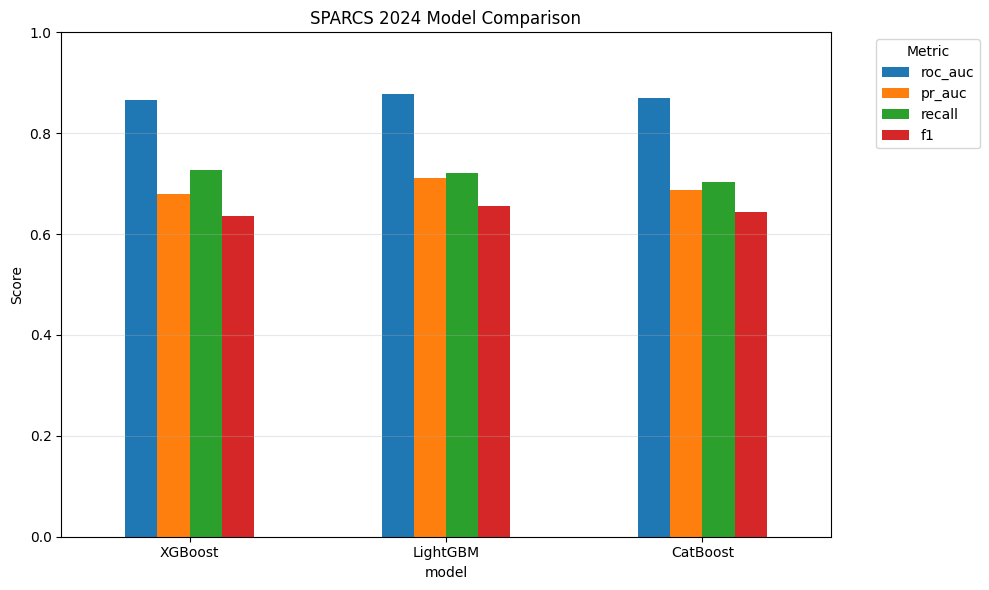

In [34]:
# Visualize Model Comparison

plot_df = test_metrics.set_index("model")[["roc_auc", "pr_auc", "recall", "f1"]]

ax = plot_df.plot(kind="bar", figsize=(10, 6))

plt.title("SPARCS 2024 Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [35]:
# Print Final Selection Summary

print("Best Model:", best_model_info["best_model"])
print("Model File:", best_model_info["best_model_file"])
print("Metadata File:", best_model_info["best_metadata_file"])
print("Selection Reason:", best_model_info["selection_reason"])

pd.DataFrame([best_model_row])

Best Model: LightGBM
Model File: lightgbm_sparcs_los_pipeline.joblib
Metadata File: lightgbm_sparcs_metadata.joblib
Selection Reason: Selected based on highest test ROC-AUC and PR-AUC among models with recall above 0.70.


,model,dataset,split,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1
3,LightGBM,SPARCS 2024,test,0.6,0.87812,0.711166,0.81748,0.601391,0.720916,0.655751


## Summary

XGBoost, LightGBM, and CatBoost were compared using the same SPARCS 2024 processed dataset, selected feature schema, and train/validation/test split.

The comparison focused on ROC-AUC, PR-AUC, recall, and F1-score. Recall was prioritized because missing prolonged LOS cases may reduce the usefulness of the screening system.

The best model was selected from models with recall above 0.70, prioritizing ROC-AUC and PR-AUC. The final selection metadata and comparison tables were saved for deployment and SHAP explanation.